In [1]:
import os
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

# Path configurations
PROCESSED_DATA_DIR = "../data/processed/"
MODELS_DIR = "../models/"
REPORTS_DIR = "../notebooks/"

# Load processed datasets (Using test sets for global evaluation)
X_test_eco = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "ecommerce_X_test.csv"))
X_test_bank = pd.read_csv(os.path.join(PROCESSED_DATA_DIR, "bank_X_test.csv"))

# Load our pre-trained best Random Forest models from Task 2
model_eco = joblib.load(os.path.join(MODELS_DIR, "ecommerce_best_rf_model.pkl"))
model_bank = joblib.load(os.path.join(MODELS_DIR, "bank_best_rf_model.pkl"))

print("SHAP explainability environment successfully configured.")

SHAP explainability environment successfully configured.


--- Computing SHAP Values for E-commerce Stream ---


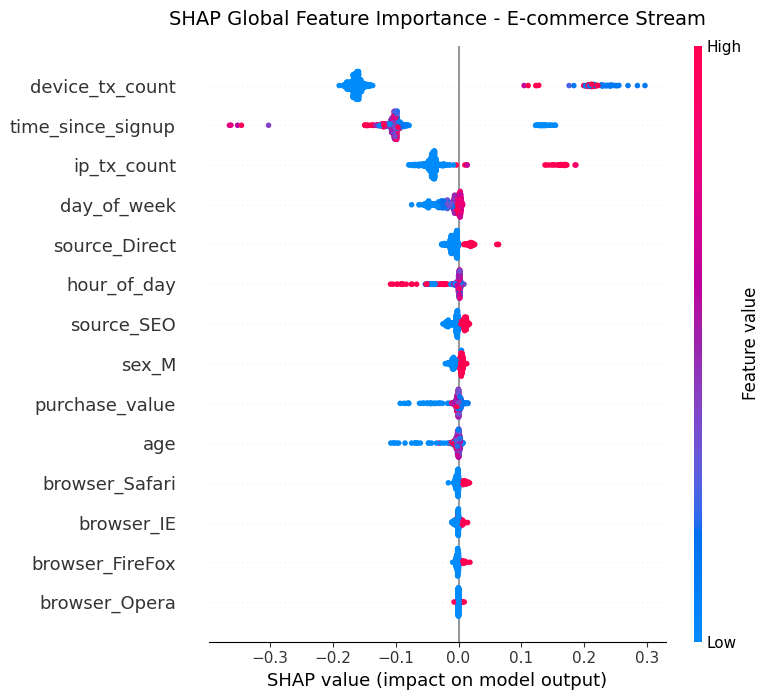

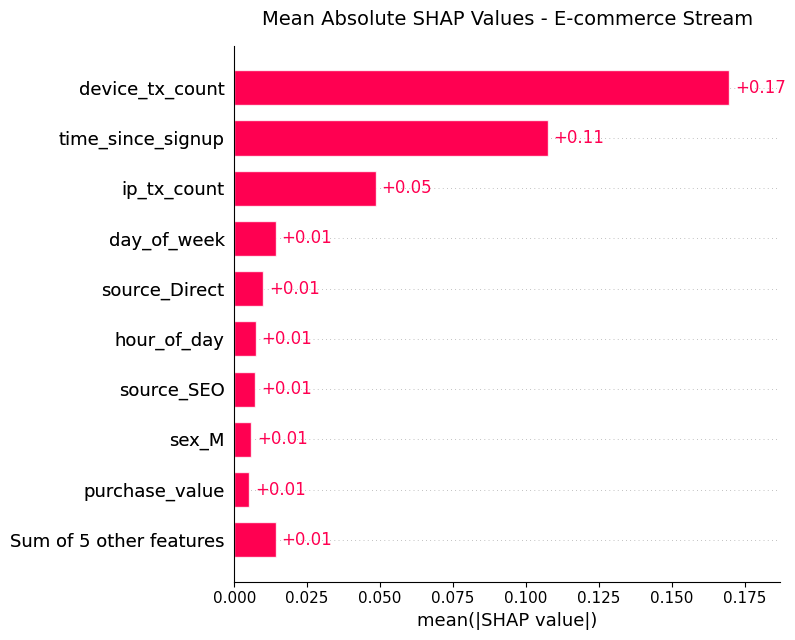

In [2]:
print("--- Computing SHAP Values for E-commerce Stream ---")

# Use a sample subset of test data to accelerate SHAP computation
eco_sample = X_test_eco.sample(n=500, random_state=42)

# Initialize TreeExplainer for Tree-based ensembles
explainer_eco = shap.TreeExplainer(model_eco)
shap_values_eco = explainer_eco(eco_sample)

# Generate SHAP Summary Plot (Beeswarm) to show feature impact distribution
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_eco[:, :, 1], eco_sample, show=False) # Index 1 targets the Fraud class
plt.title("SHAP Global Feature Importance - E-commerce Stream", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "ecommerce_shap_summary.png"))
plt.show()

# Generate SHAP Bar Plot for absolute mean importance
plt.figure(figsize=(10, 6))
shap.plots.bar(shap_values_eco[:, :, 1], show=False)
plt.title("Mean Absolute SHAP Values - E-commerce Stream", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "ecommerce_shap_bar.png"))
plt.show()

--- Computing SHAP Values for Bank Credit Card Stream ---


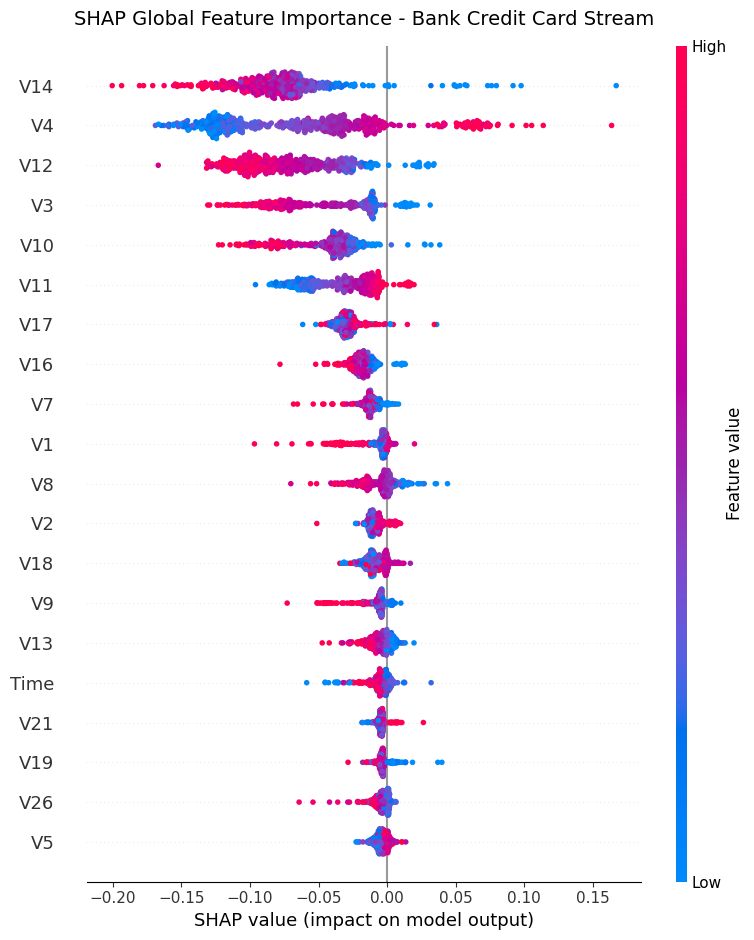

In [3]:
print("--- Computing SHAP Values for Bank Credit Card Stream ---")

bank_sample = X_test_bank.sample(n=500, random_state=42)

explainer_bank = shap.TreeExplainer(model_bank)
shap_values_bank = explainer_bank(bank_sample)

# Generate SHAP Summary Plot for Bank Credit Card Stream
plt.figure(figsize=(10, 6))
shap.summary_plot(shap_values_bank[:, :, 1], bank_sample, show=False)
plt.title("SHAP Global Feature Importance - Bank Credit Card Stream", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig(os.path.join(REPORTS_DIR, "bank_shap_summary.png"))
plt.show()